In [1]:
import os

base_path = "/kaggle/input"
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:  # don't spam every filename, just peek
        print(f"{indent}  → {len(files)} files")
        continue

input/
  datasets/
    ashenafifasilkebede/
      → 0 files
      dataset/
        → 0 files
        val/
          → 0 files
          OSCC/
            → 92 files
          Normal/
            → 28 files
        test/
          → 0 files
          OSCC/
            → 95 files
          Normal/
            → 31 files
        train/
          → 0 files
          OSCC/
            → 2511 files
          Normal/
            → 2435 files
  notebooks/
    amanx98/
      → 0 files
      oral-cancer-cvmodel/
        → 5 files
        .gradio/
          → 1 files
        checkpoints/
          → 2 files
        hf_space_export/
          → 1 files
        __results___files/
          → 1 files


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_ROOT = "/kaggle/input/datasets/ashenafifasilkebede/dataset"
IMG_SIZE = 224
BATCH_SIZE = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val", transform=eval_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=eval_transform)

print("Class mapping:", train_ds.class_to_idx)
print("Train size:", len(train_ds), "| Val size:", len(val_ds), "| Test size:", len(test_ds))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# sanity check
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape, "| Labels shape:", labels.shape)

Using device: cuda
Class mapping: {'Normal': 0, 'OSCC': 1}
Train size: 4946 | Val size: 120 | Test size: 126
Batch shape: torch.Size([32, 3, 224, 224]) | Labels shape: torch.Size([32])


In [3]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load pretrained backbone
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

# Freeze all backbone layers — their weights won't update yet
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier head with one for our 2 classes
# EfficientNetB0's original head is model.classifier = Sequential(Dropout, Linear(1280, 1000))
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 2)
)

model = model.to(device)

# Sanity check: confirm only the head is trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 209MB/s]


Trainable params: 2,562 / 4,010,110


In [4]:
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(is_train)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

EPOCHS_STAGE1 = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS_STAGE1):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE1} ({time.time()-start:.1f}s) | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Epoch 1/5 (76.9s) | Train loss: 0.5182, acc: 0.7438 | Val loss: 0.4167, acc: 0.8000
Epoch 2/5 (52.8s) | Train loss: 0.4352, acc: 0.8031 | Val loss: 0.3872, acc: 0.8083
Epoch 3/5 (52.8s) | Train loss: 0.4112, acc: 0.8140 | Val loss: 0.3562, acc: 0.8000
Epoch 4/5 (54.8s) | Train loss: 0.4073, acc: 0.8132 | Val loss: 0.3514, acc: 0.8167
Epoch 5/5 (53.5s) | Train loss: 0.3908, acc: 0.8279 | Val loss: 0.3675, acc: 0.8083


In [5]:
import os
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
torch.save(model.state_dict(), "/kaggle/working/checkpoints/stage1_head.pth")
print("Saved.")

Saved.


In [6]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Rebuild the same architecture
model = efficientnet_b0(weights=None)  # no need to redownload ImageNet weights
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 2)
)
model.load_state_dict(torch.load("/kaggle/input/notebooks/amanx98/oral-cancer-cvmodel/checkpoints/stage1_head.pth"))
model = model.to(device)
print("Checkpoint loaded.")

# Rebuild data loaders (same as before)
DATA_ROOT = "/kaggle/input/datasets/ashenafifasilkebede/dataset"
IMG_SIZE = 224
BATCH_SIZE = 32
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val", transform=eval_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Data ready.")

Using device: cuda
Checkpoint loaded.
Data ready.


In [7]:
# EfficientNetB0's backbone is model.features (a Sequential of 9 blocks: 0-8)
# Let's see the structure first
for i, block in enumerate(model.features):
    print(i, block.__class__.__name__)

0 Conv2dNormActivation
1 Sequential
2 Sequential
3 Sequential
4 Sequential
5 Sequential
6 Sequential
7 Sequential
8 Conv2dNormActivation


In [8]:
# Unfreeze the last few blocks (e.g. last 2-3) + the classifier head
# Keep early blocks (generic feature detectors) frozen
for param in model.parameters():
    param.requires_grad = False  # start fully frozen again

for param in model.features[-3:].parameters():  # unfreeze last 3 blocks
    param.requires_grad = True

for param in model.classifier.parameters():  # head always trainable
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 3,158,302 / 4,010,110


In [9]:
import torch.optim as optim

optimizer = optim.Adam([
    {"params": model.features[-3:].parameters(), "lr": 1e-5},  # backbone: tiny LR
    {"params": model.classifier.parameters(), "lr": 1e-4},      # head: bigger LR
])
criterion = nn.CrossEntropyLoss()

In [10]:
import time

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(is_train)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
import os
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

In [12]:
EPOCHS_STAGE2 = 10
best_val_acc = 0.0
history_s2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS_STAGE2):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history_s2["train_loss"].append(train_loss)
    history_s2["train_acc"].append(train_acc)
    history_s2["val_loss"].append(val_loss)
    history_s2["val_acc"].append(val_acc)

    improved = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/checkpoints/stage2_best.pth")
        improved = " ← saved (best so far)"

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE2} ({time.time()-start:.1f}s) | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}{improved}")

Epoch 1/10 (56.5s) | Train loss: 0.3835, acc: 0.8267 | Val loss: 0.3359, acc: 0.8083 ← saved (best so far)
Epoch 2/10 (54.0s) | Train loss: 0.3384, acc: 0.8532 | Val loss: 0.3295, acc: 0.8250 ← saved (best so far)
Epoch 3/10 (56.3s) | Train loss: 0.3170, acc: 0.8627 | Val loss: 0.3248, acc: 0.8333 ← saved (best so far)
Epoch 4/10 (52.9s) | Train loss: 0.3063, acc: 0.8676 | Val loss: 0.3222, acc: 0.8417 ← saved (best so far)
Epoch 5/10 (52.6s) | Train loss: 0.2757, acc: 0.8797 | Val loss: 0.3243, acc: 0.8417
Epoch 6/10 (54.2s) | Train loss: 0.2708, acc: 0.8926 | Val loss: 0.3177, acc: 0.8417
Epoch 7/10 (53.9s) | Train loss: 0.2547, acc: 0.8922 | Val loss: 0.3233, acc: 0.8417
Epoch 8/10 (53.9s) | Train loss: 0.2340, acc: 0.9056 | Val loss: 0.3205, acc: 0.8417
Epoch 9/10 (54.0s) | Train loss: 0.2304, acc: 0.9048 | Val loss: 0.3318, acc: 0.8417
Epoch 10/10 (56.0s) | Train loss: 0.2164, acc: 0.9102 | Val loss: 0.3360, acc: 0.8500 ← saved (best so far)


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the best checkpoint (in case memory state drifted during training)
model.load_state_dict(torch.load("/kaggle/working/checkpoints/stage2_best.pth"))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class "OSCC"
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=["Normal", "OSCC"]))

print("=== Confusion Matrix ===")
cm = confusion_matrix(all_labels, all_preds)
print(cm)
print("(rows = actual, cols = predicted, order: Normal, OSCC)")

auc = roc_auc_score(all_labels, all_probs)
print(f"\nROC-AUC: {auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.80      0.77      0.79        31
        OSCC       0.93      0.94      0.93        95

    accuracy                           0.90       126
   macro avg       0.86      0.86      0.86       126
weighted avg       0.90      0.90      0.90       126

=== Confusion Matrix ===
[[24  7]
 [ 6 89]]
(rows = actual, cols = predicted, order: Normal, OSCC)

ROC-AUC: 0.9409


In [14]:
torch.set_grad_enabled(True)

torch.autograd.grad_mode.set_grad_enabled(mode=True)

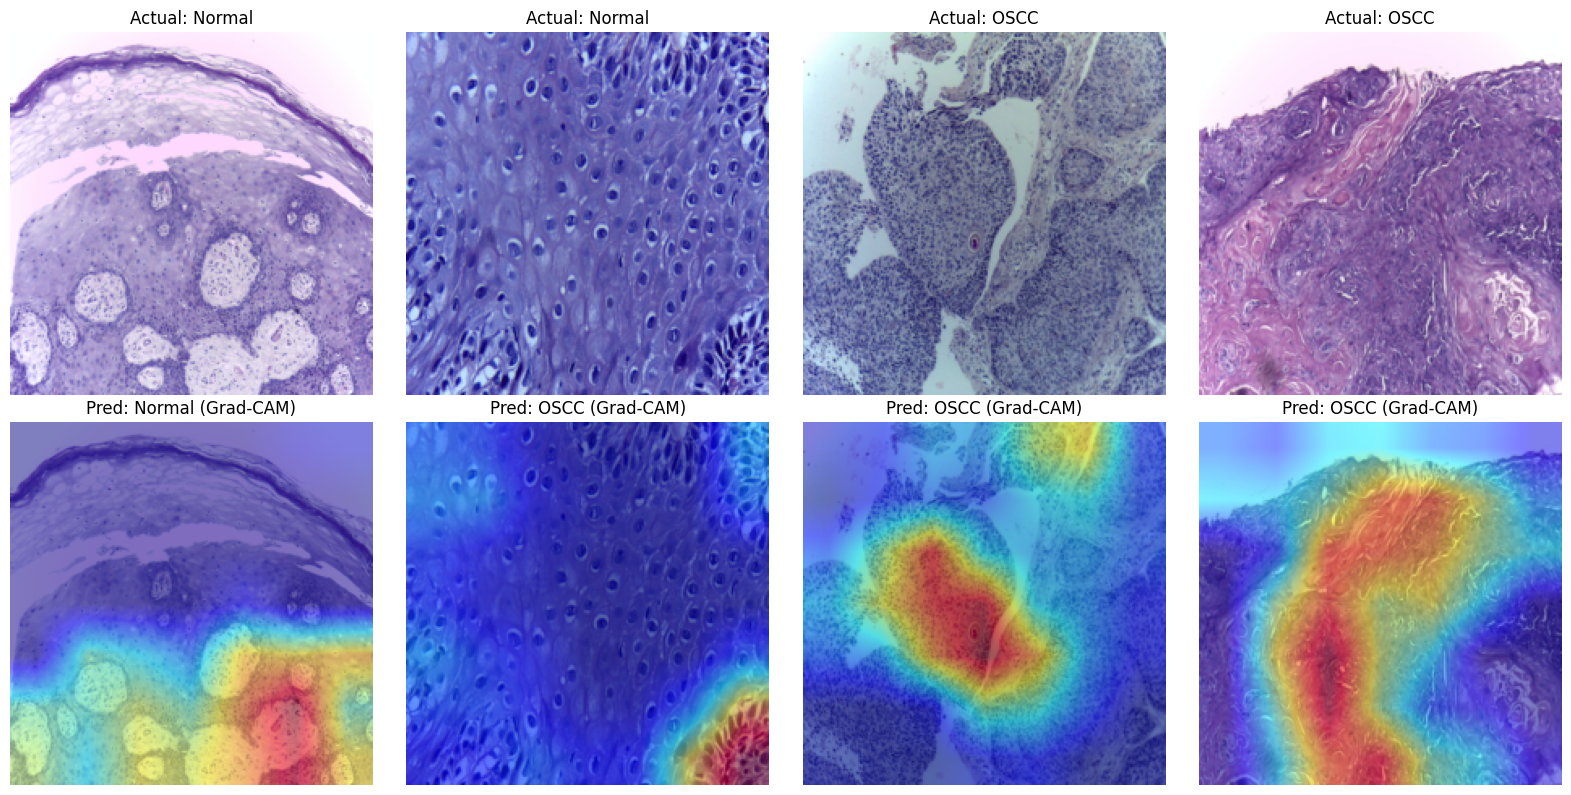

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Grad-CAM hook setup — we need the gradients and activations of the last conv layer
gradients = []
activations = []

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def save_activation(module, input, output):
    activations.append(output)

# EfficientNetB0's last conv block before pooling
target_layer = model.features[-1]
handle_fwd = target_layer.register_forward_hook(save_activation)
handle_bwd = target_layer.register_full_backward_hook(save_gradient)

def generate_gradcam(model, image_tensor, class_idx):
    gradients.clear()
    activations.clear()

    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad_()

    output = model(image_tensor)
    model.zero_grad()
    output[0, class_idx].backward()

    grads = gradients[0].squeeze(0)       # [C, H, W]
    acts = activations[0].squeeze(0)      # [C, H, W]

    weights = grads.mean(dim=(1, 2))      # global average pool the gradients
    cam = torch.zeros(acts.shape[1:], dtype=torch.float32).to(device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)
    cam = cam.cpu().detach().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def unnormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    return np.clip(img, 0, 1)

# Try it on a few test images
class_names = ["Normal", "OSCC"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img_tensor, label = test_ds[i * 20]  # spread across the test set
    pred_idx = model(img_tensor.unsqueeze(0).to(device)).argmax(dim=1).item()

    cam = generate_gradcam(model, img_tensor, pred_idx)
    orig_img = unnormalize(img_tensor)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * orig_img + 0.5 * heatmap

    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f"Actual: {class_names[label]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Pred: {class_names[pred_idx]} (Grad-CAM)")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_examples.png", dpi=150)
plt.show()

handle_fwd.remove()
handle_bwd.remove()

In [16]:
!pip install -q gradio

In [17]:
import gradio as gr
from PIL import Image

def predict_and_explain(input_image):
    # Preprocess exactly like eval_transform
    img_tensor = eval_transform(input_image.convert("RGB")).to(device)

    # Prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        confidence = probs[pred_idx].item()

    # Grad-CAM (needs grad enabled)
    torch.set_grad_enabled(True)
    cam = generate_gradcam(model, img_tensor, pred_idx)
    torch.set_grad_enabled(False)

    orig_img = unnormalize(img_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.5 * orig_img + 0.5 * heatmap, 0, 1)
    overlay_img = Image.fromarray((overlay * 255).astype(np.uint8))

    label = class_names[pred_idx]
    result_text = f"Prediction: {label}\nConfidence: {confidence:.1%}"

    return result_text, overlay_img

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="pil", label="Upload a histopathology slide image"),
    outputs=[
        gr.Textbox(label="Result"),
        gr.Image(label="Grad-CAM: what the model focused on")
    ],
    title="Oral Cancer Histopathology Classifier",
    description="Upload an H&E-stained oral tissue image. Model classifies Normal vs OSCC (Oral Squamous Cell Carcinoma) and shows which regions influenced the decision.\n\n⚠️ Research/portfolio demo only — not a diagnostic tool.",
    examples=None
)

demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fc8f5ce8f64517646c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
import os
export_dir = "/kaggle/working/hf_space_export"
os.makedirs(export_dir, exist_ok=True)

In [19]:
app_py = '''
import torch
import torch.nn as nn
import numpy as np
import cv2
import gradio as gr
from PIL import Image
from torchvision import transforms
from torchvision.models import efficientnet_b0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
class_names = ["Normal", "OSCC"]
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

model = efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(num_features, 2))
model.load_state_dict(torch.load("model.pth", map_location=device))
model = model.to(device)
model.eval()

gradients = []
activations = []

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def save_activation(module, input, output):
    activations.append(output)

target_layer = model.features[-1]
target_layer.register_forward_hook(save_activation)
target_layer.register_full_backward_hook(save_gradient)

def unnormalize(img_tensor):
    img = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    return np.clip(img, 0, 1)

def generate_gradcam(image_tensor, class_idx):
    gradients.clear()
    activations.clear()
    torch.set_grad_enabled(True)

    inp = image_tensor.unsqueeze(0).to(device)
    inp.requires_grad_()
    output = model(inp)
    model.zero_grad()
    output[0, class_idx].backward()

    grads = gradients[0].squeeze(0)
    acts = activations[0].squeeze(0)
    weights = grads.mean(dim=(1, 2))

    cam = torch.zeros(acts.shape[1:], dtype=torch.float32).to(device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    torch.set_grad_enabled(False)
    return cam

def predict_and_explain(input_image):
    img_tensor = eval_transform(input_image.convert("RGB")).to(device)

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        confidence = probs[pred_idx].item()

    cam = generate_gradcam(img_tensor, pred_idx)
    orig_img = unnormalize(img_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.5 * orig_img + 0.5 * heatmap, 0, 1)
    overlay_img = Image.fromarray((overlay * 255).astype(np.uint8))

    label = class_names[pred_idx]
    result_text = f"Prediction: {label}\\nConfidence: {confidence:.1%}"
    return result_text, overlay_img

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="pil", label="Upload a histopathology slide image (best results with high-res, uncompressed images)"),
    outputs=[gr.Textbox(label="Result"), gr.Image(label="Grad-CAM: what the model focused on")],
    title="Oral Cancer Histopathology Classifier",
    description="Upload an H&E-stained oral tissue image. Classifies Normal vs OSCC (Oral Squamous Cell Carcinoma) and shows which regions influenced the decision.\\n\\nTest accuracy: 88%% | ROC-AUC: 0.937\\n\\n\\u26a0\\ufe0f Research/portfolio demo only \\u2014 not a diagnostic tool.",
)

demo.launch()
'''

with open(os.path.join(export_dir, "app.py"), "w") as f:
    f.write(app_py)

print("app.py written.")

app.py written.


In [20]:
import os
import shutil

export_dir = "/kaggle/working/hf_space_export"
os.makedirs(export_dir, exist_ok=True)

shutil.copy(
    "/kaggle/working/checkpoints/stage2_best.pth",
    os.path.join(export_dir, "model.pth")
)

requirements = """torch
torchvision
gradio
opencv-python-headless
numpy
Pillow
"""
with open(os.path.join(export_dir, "requirements.txt"), "w") as f:
    f.write(requirements)

print("Exported:", os.listdir(export_dir))

Exported: ['model.pth', 'requirements.txt', 'app.py']


In [21]:
import numpy as np

# Use the backbone's output right before the classifier (the pooled feature vector)
feature_extractor = nn.Sequential(model.features, model.avgpool, nn.Flatten())
feature_extractor.eval()

all_features = []

# Use eval_transform (no augmentation) even on train images, for clean stats
train_ds_clean = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=eval_transform)
clean_loader = DataLoader(train_ds_clean, batch_size=64, shuffle=False, num_workers=2)

with torch.no_grad():
    for images, _ in clean_loader:
        images = images.to(device)
        feats = feature_extractor(images)
        all_features.append(feats.cpu().numpy())

all_features = np.concatenate(all_features, axis=0)
print("Feature matrix shape:", all_features.shape)  # should be (4946, 1280)

Feature matrix shape: (4946, 1280)


In [22]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Rebuild architecture and load Stage 2 fine-tuned weights
model = efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(num_features, 2))

# Point at your Stage 2 checkpoint — adjust path if it's under a different "Add Input" mount
model.load_state_dict(torch.load("/kaggle/input/notebooks/amanx98/oral-cancer-cvmodel/checkpoints/stage2_best.pth"))
model = model.to(device)
model.eval()
print("Stage 2 checkpoint loaded.")

# Rebuild transforms + data
DATA_ROOT = "/kaggle/input/datasets/ashenafifasilkebede/dataset"
IMG_SIZE = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Setup complete.")

Using device: cuda
Stage 2 checkpoint loaded.
Setup complete.


In [23]:
import numpy as np

feature_extractor = nn.Sequential(model.features, model.avgpool, nn.Flatten())
feature_extractor.eval()

all_features = []

train_ds_clean = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=eval_transform)
clean_loader = DataLoader(train_ds_clean, batch_size=64, shuffle=False, num_workers=2)

with torch.no_grad():
    for images, _ in clean_loader:
        images = images.to(device)
        feats = feature_extractor(images)
        all_features.append(feats.cpu().numpy())

all_features = np.concatenate(all_features, axis=0)
print("Feature matrix shape:", all_features.shape)

Feature matrix shape: (4946, 1280)


In [24]:
from sklearn.covariance import EmpiricalCovariance

cov_estimator = EmpiricalCovariance().fit(all_features)
feature_mean = cov_estimator.location_
feature_cov_inv = cov_estimator.precision_

train_distances = cov_estimator.mahalanobis(all_features)
print("Train distance stats — min:", train_distances.min(), "max:", train_distances.max(),
      "mean:", train_distances.mean(), "99th pct:", np.percentile(train_distances, 99))

ood_threshold = np.percentile(train_distances, 99.5)
print("OOD threshold:", ood_threshold)

import os
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
np.save("/kaggle/working/checkpoints/feature_mean.npy", feature_mean)
np.save("/kaggle/working/checkpoints/feature_cov_inv.npy", feature_cov_inv)
np.save("/kaggle/working/checkpoints/ood_threshold.npy", np.array([ood_threshold]))
print("Saved OOD detection stats.")

Train distance stats — min: 550.4266421054535 max: 2385.8508835900875 mean: 1280.000000001011 99th pct: 1868.5915442577912
OOD threshold: 1930.2165029964121
Saved OOD detection stats.
